# 04 · Probability, Permutations and Combinations

Probability is the language of uncertainty. Every p-value, every A/B test and every classification model speaks it. This notebook covers the basic rules.

**What you will learn here**

1. What probability is, and why frequencies settle down (law of large numbers)
2. The addition rule (OR): mutually exclusive and not mutually exclusive events
3. The multiplication rule (AND): independent and dependent events
4. Conditional probability and a first look at Bayes' theorem
5. Permutations and combinations

## The dataset: Titanic passengers

| | |
|---|---|
| **Name** | Titanic |
| **Source** | [seaborn-data on GitHub](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv), the same passenger list as the Kaggle "Titanic" competition training set |
| **Licence** | Historical records, freely used for teaching |
| **Rows** | 891 passengers |

A copy is saved in `data/titanic.csv`. Columns used here:

| Column | Meaning |
|---|---|
| `survived` | 1 = survived, 0 = died |
| `class` | Ticket class: First, Second, Third |
| `sex` | male / female |
| `age` | Age in years (some missing) |
| `embark_town` | Port where the passenger boarded |

In [1]:
import math
from itertools import permutations, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

titanic = pd.read_csv("../data/titanic.csv")
titanic[["survived", "class", "sex", "age", "embark_town"]].head()

,survived,class,sex,age,embark_town
0,0,Third,male,22.0,Southampton
1,1,First,female,38.0,Cherbourg
2,1,Third,female,26.0,Southampton
3,1,First,female,35.0,Southampton
4,0,Third,male,35.0,Southampton


---
## 1. What is probability?

> **Theory.**
>
> **Probability** is a number between 0 and 1 that measures how likely an event is. 0 = impossible, 1 = certain.

**Formula** (when all outcomes are equally likely)

$$P(A) = \frac{\text{number of ways A can happen}}{\text{total number of possible outcomes}}$$

**Small examples, by hand**

- Roll a die. P(getting a 6) = 1 / 6 = **0.167**
- Toss a coin. P(head) = 1 / 2 = **0.5**
- Pick a random Titanic passenger. P(survived) = number who survived / 891

In [2]:
survived_count = titanic["survived"].sum()
total = len(titanic)

p_survived = survived_count / total
print(f"{survived_count} survived out of {total}")
print(f"P(survived) = {p_survived:.3f}")

342 survived out of 891
P(survived) = 0.384


So if we pick one passenger at random, there is a 38.4% chance this person survived.

### Law of large numbers

"P(6) = 1/6" does not mean that every 6 rolls contain exactly one 6. It means that **over many rolls**, the share of sixes gets closer and closer to 1/6. Let's simulate it.

In [3]:
np.random.seed(1)
rolls = np.random.randint(1, 7, size=5000)

is_six = (rolls == 6)
running_share = np.cumsum(is_six) / np.arange(1, len(rolls) + 1)

for n in [10, 100, 1000, 5000]:
    print(f"after {n:4d} rolls: share of sixes = {running_share[n - 1]:.3f}")

after   10 rolls: share of sixes = 0.200
after  100 rolls: share of sixes = 0.160
after 1000 rolls: share of sixes = 0.170
after 5000 rolls: share of sixes = 0.172


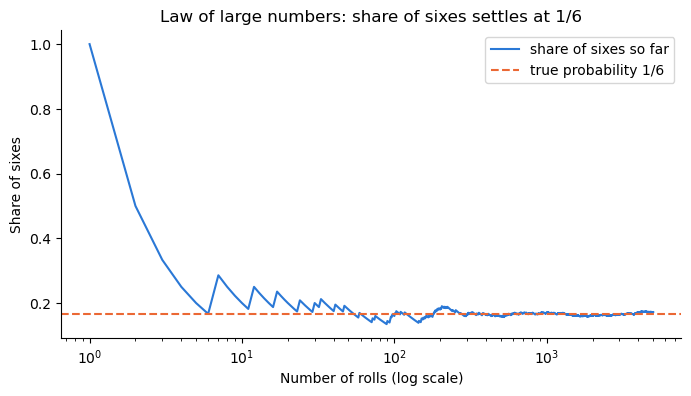

In [4]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(rolls) + 1), running_share, color=BLUE, linewidth=1.5, label="share of sixes so far")
ax.axhline(1 / 6, color=ORANGE, linestyle="--", label="true probability 1/6")
ax.set_xscale("log")
ax.set_title("Law of large numbers: share of sixes settles at 1/6")
ax.set_xlabel("Number of rolls (log scale)")
ax.set_ylabel("Share of sixes")
ax.legend()
plt.show()

With few rolls the share jumps around a lot. After thousands of rolls it settles near 0.167. This is also why small samples in A/B tests are dangerous: early numbers are noisy.

---
## 2. Addition rule (OR)

**Why do we need it?** To answer questions like "what is the chance that a passenger was in first class **or** second class?"

### 2a. Mutually exclusive events

> Two events are **mutually exclusive** if they cannot happen at the same time. A passenger cannot be in first class and second class at once. A die cannot show 1 and 3 at once.

**Formula**

$$P(A \text{ or } B) = P(A) + P(B)$$

**By hand:** P(die shows 1 or 3 or 6) = 1/6 + 1/6 + 1/6 = 3/6 = **0.5**

On Titanic: 216 first class and 184 second class passengers out of 891.

P(first or second) = 216/891 + 184/891 = 400/891 = **0.449**

In [5]:
p_first = (titanic["class"] == "First").mean()
p_second = (titanic["class"] == "Second").mean()

print(f"P(first) + P(second)        = {p_first + p_second:.3f}")
print(f"Counting directly           = {titanic['class'].isin(['First', 'Second']).mean():.3f}")

P(first) + P(second)        = 0.449
Counting directly           = 0.449


### 2b. Not mutually exclusive events

> Events can happen together. A card can be a queen **and** a heart. A passenger can be female **and** a survivor. If we simply add, the overlap gets counted twice, so we subtract it once.

**Formula**

$$P(A \text{ or } B) = P(A) + P(B) - P(A \text{ and } B)$$

**By hand (cards):** P(queen or heart) = 4/52 + 13/52 − 1/52 = 16/52 = **0.308**

On Titanic, let's look at the counts first.

In [6]:
# docs: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html
counts = pd.crosstab(titanic["sex"], titanic["survived"], margins=True, margins_name="total")
counts.columns = ["died", "survived", "total"]
counts

,died,survived,total
sex,,,
female,81,233,314
male,468,109,577
total,549,342,891


**By hand:** P(female or survived)

- P(female) = 314 / 891
- P(survived) = 342 / 891
- P(female and survived) = 233 / 891

P(female or survived) = (314 + 342 − 233) / 891 = 423 / 891 = **0.475**

In [7]:
is_female = titanic["sex"] == "female"
is_survivor = titanic["survived"] == 1

p_female = is_female.mean()
p_both = (is_female & is_survivor).mean()

formula_answer = p_female + p_survived - p_both
direct_answer = (is_female | is_survivor).mean()

print(f"Using the formula: {formula_answer:.3f}")
print(f"Counting directly: {direct_answer:.3f}")

Using the formula: 0.475
Counting directly: 0.475


> **Check:** Same answer. If we forgot to subtract the overlap, we would get 0.736, which is far too high.

---
## 3. Multiplication rule (AND)

### 3a. Independent events

> Two events are **independent** if one does not change the chance of the other. Two separate die rolls are independent.

**Formula**

$$P(A \text{ and } B) = P(A) \times P(B)$$

**By hand:** P(roll a 5, then roll a 4) = 1/6 × 1/6 = 1/36 = **0.028**

In [8]:
np.random.seed(2)
first_roll = np.random.randint(1, 7, size=100_000)
second_roll = np.random.randint(1, 7, size=100_000)

simulated = ((first_roll == 5) & (second_roll == 4)).mean()
print(f"Formula : {1 / 36:.4f}")
print(f"Simulated (100,000 tries): {simulated:.4f}")

Formula : 0.0278
Simulated (100,000 tries): 0.0283


### 3b. Dependent events

> Events are **dependent** when the first one changes the chance of the second. Classic case: drawing **without putting back**.

**Formula**

$$P(A \text{ and } B) = P(A) \times P(B \mid A)$$

$P(B \mid A)$ is read "probability of B **given** A", the probability of B once we know A already happened.

**By hand (bag of marbles):** 3 red and 2 green marbles. Draw two without putting back. P(both red)?

- First red: 3/5
- Second red, given the first was red: 2 red left out of 4 → 2/4
- P(both red) = 3/5 × 2/4 = 6/20 = **0.3**

Cards: P(queen, then ace) = 4/52 × 4/51 = **0.006** (after one card is out, 51 remain).

On Titanic: pick 2 different passengers at random. P(both survived)?

342/891 × 341/890 = **0.147**

In [9]:
p_both_by_formula = (342 / 891) * (341 / 890)
print(f"Formula: {p_both_by_formula:.4f}")

np.random.seed(3)
tries = 50_000
both_survived = 0
survived_array = titanic["survived"].to_numpy()
for _ in range(tries):
    two_people = np.random.choice(survived_array, size=2, replace=False)
    if two_people.sum() == 2:
        both_survived += 1

print(f"Simulated ({tries:,} tries): {both_survived / tries:.4f}")

Formula: 0.1471
Simulated (50,000 tries): 0.1453


> **Check:** The simulation agrees with the formula.

---
## 4. Conditional probability

> **Theory.** Conditional probability narrows down the group we look at.

**Formula**

$$P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$$

In words: among the cases where B happened, what share also has A?

**Why do we need it?** Almost every interesting question in data work is conditional. "What is the conversion rate **for users who saw the new page**?" "What is the chance of fraud **given** this transaction is from a new device?"

**By hand on Titanic**

- P(survived | female) = 233 / 314 = **0.742**
- P(survived | male) = 109 / 577 = **0.189**

In [10]:
p_survived_given_female = titanic.loc[is_female, "survived"].mean()
p_survived_given_male = titanic.loc[~is_female, "survived"].mean()

print(f"P(survived | female) = {p_survived_given_female:.3f}")
print(f"P(survived | male)   = {p_survived_given_male:.3f}")

P(survived | female) = 0.742
P(survived | male)   = 0.189


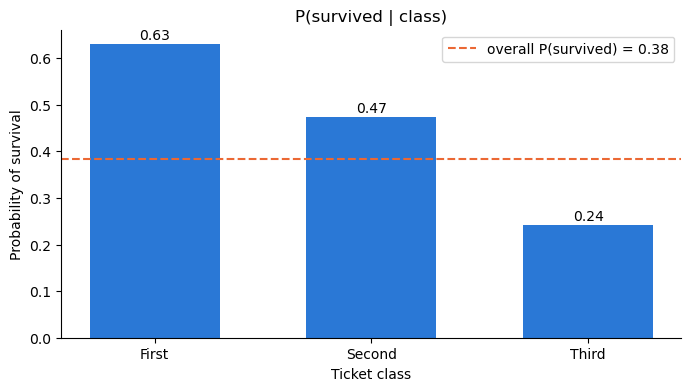

In [11]:
by_class = titanic.groupby("class")["survived"].mean().reindex(["First", "Second", "Third"])

fig, ax = plt.subplots()
ax.bar(by_class.index, by_class.values, color=BLUE, width=0.6)
ax.axhline(p_survived, color=ORANGE, linestyle="--", label=f"overall P(survived) = {p_survived:.2f}")
for i, value in enumerate(by_class.values):
    ax.text(i, value + 0.01, f"{value:.2f}", ha="center")
ax.set_title("P(survived | class)")
ax.set_xlabel("Ticket class")
ax.set_ylabel("Probability of survival")
ax.legend()
plt.show()

Survival depended strongly on ticket class: 63% in first class, only 24% in third class. The overall 38% hides these big differences.

### Are sex and survival independent?

If two events are independent, then $P(A \text{ and } B) = P(A) \times P(B)$. Let's test it.

In [12]:
print(f"P(female) x P(survived) = {p_female * p_survived:.3f}   <- what independence would give")
print(f"P(female and survived)  = {p_both:.3f}   <- what really happened")

P(female) x P(survived) = 0.135   <- what independence would give
P(female and survived)  = 0.262   <- what really happened


0.262 is almost twice 0.135. So sex and survival were clearly **not** independent ("women and children first"). In notebook 06 we will test this kind of question properly with the chi-square test.

### Bayes' theorem (a first look)

Bayes' theorem flips a conditional probability around:

$$P(A \mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

Question: we know a passenger **survived**. What is the chance this person was female?

**By hand:**

$$P(\text{female} \mid \text{survived}) = \frac{0.742 \times 0.352}{0.384} = 0.681$$

Check by counting: 233 women among 342 survivors = 233 / 342 = **0.681**.

In [13]:
bayes_answer = p_survived_given_female * p_female / p_survived
count_answer = titanic.loc[is_survivor, "sex"].eq("female").mean()

print(f"Bayes' theorem   : {bayes_answer:.3f}")
print(f"Direct counting  : {count_answer:.3f}")

Bayes' theorem   : 0.681
Direct counting  : 0.681


Notice the two are very different numbers: P(survived | female) = 0.742 but P(female | survived) = 0.681. Mixing up the direction of a conditional probability is one of the most common mistakes in statistics. Bayes' theorem is the base of spam filters and the Naive Bayes classifier.

Read more: [Bayes' theorem (Wikipedia)](https://en.wikipedia.org/wiki/Bayes%27_theorem) · [Seeing Theory: compound probability](https://seeing-theory.brown.edu/compound-probability/index.html)

---
## 5. Permutations and combinations

**Why do we need them?** To count outcomes when listing them all is impossible. They also appear in the binomial distribution (notebook 08) and when we count how many comparisons an experiment makes.

> **Theory**
>
> | | Order matters? | Example |
> |---|---|---|
> | **Permutation** | Yes | Gold, silver, bronze winners. ABC is different from CBA |
> | **Combination** | No | Picking a team of 3. {A, B, C} is the same team as {C, B, A} |

**Formulas**

$$^nP_r = \frac{n!}{(n-r)!} \qquad\qquad ^nC_r = \binom{n}{r} = \frac{n!}{r!\,(n-r)!}$$

$n!$ ("n factorial") = n × (n − 1) × ... × 1. For example 4! = 4 × 3 × 2 × 1 = 24.

**Small example.** A factory makes 6 types of chocolate. A child writes down the first 3 types they see.

**By hand**

- Ordered lists (permutations): 6 × 5 × 4 = **120**
- Different groups of 3, ignoring order (combinations): 120 / 3! = 120 / 6 = **20**

We divide by 3! because each group of 3 can be written in 3! = 6 different orders.

In [14]:
chocolates = ["Dairy Milk", "Gems", "Eclairs", "KitKat", "5 Star", "Munch"]

# docs: https://docs.python.org/3/library/itertools.html#itertools.permutations
ordered = list(permutations(chocolates, 3))
groups = list(combinations(chocolates, 3))

print("Permutations by listing:", len(ordered), "| formula:", math.perm(6, 3))
# docs: https://docs.python.org/3/library/math.html#math.comb
print("Combinations by listing:", len(groups), "| formula:", math.comb(6, 3))
print()
print("First 3 permutations:", ordered[:3])
print("First 3 combinations:", groups[:3])

Permutations by listing: 120 | formula: 120
Combinations by listing: 20 | formula: 20

First 3 permutations: [('Dairy Milk', 'Gems', 'Eclairs'), ('Dairy Milk', 'Gems', 'KitKat'), ('Dairy Milk', 'Gems', '5 Star')]
First 3 combinations: [('Dairy Milk', 'Gems', 'Eclairs'), ('Dairy Milk', 'Gems', 'KitKat'), ('Dairy Milk', 'Gems', '5 Star')]


> **Check:** Listing and formula agree.

### Real use: how many comparisons?

If an experiment has 5 versions of a web page and we compare every pair, how many tests do we run?

That is $\binom{5}{2} = \frac{5!}{2! \, 3!} = 10$ tests. With 10 tests, the chance of at least one false alarm grows a lot. This is the **multiple comparisons** problem we will meet in the A/B testing notebook.

In [15]:
for versions in [2, 3, 5, 10]:
    pairs = math.comb(versions, 2)
    chance_false_alarm = 1 - (1 - 0.05) ** pairs
    print(f"{versions:2d} versions -> {pairs:2d} pairwise tests -> P(at least one false alarm) = {chance_false_alarm:.2f}")

 2 versions ->  1 pairwise tests -> P(at least one false alarm) = 0.05
 3 versions ->  3 pairwise tests -> P(at least one false alarm) = 0.14
 5 versions -> 10 pairwise tests -> P(at least one false alarm) = 0.40
10 versions -> 45 pairwise tests -> P(at least one false alarm) = 0.90


With 10 versions there are 45 pairs, and the chance of at least one "significant" result purely by luck is 90% (assuming the tests are independent and each uses a 5% threshold). Counting matters.

---
## Summary

| Rule | Formula | Use it when |
|---|---|---|
| Basic probability | favourable / total | All outcomes equally likely |
| Addition (exclusive) | P(A) + P(B) | A and B can't happen together |
| Addition (general) | P(A) + P(B) − P(A and B) | They can overlap |
| Multiplication (independent) | P(A) × P(B) | One doesn't affect the other |
| Multiplication (dependent) | P(A) × P(B \| A) | The first changes the second |
| Conditional | P(A and B) / P(B) | Looking inside a sub-group |
| Bayes | P(B \| A) P(A) / P(B) | Flipping the condition |
| Permutation | n! / (n − r)! | Order matters |
| Combination | n! / (r! (n − r)!) | Order doesn't matter |

## What's next

In **05 · Hypothesis Testing and Confidence Intervals** we use probability to decide whether a result is real or just luck: null and alternative hypotheses, p-values, significance level, type I and II errors, and confidence intervals.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 3 (probability)
- [Seeing Theory](https://seeing-theory.brown.edu/) (interactive visual explanations, Brown University), chapters on basic and compound probability
- [Conditional probability, Wikipedia](https://en.wikipedia.org/wiki/Conditional_probability) · [Combination, Wikipedia](https://en.wikipedia.org/wiki/Combination)
- [Python `math.comb` and `math.perm`](https://docs.python.org/3/library/math.html#math.comb) · [itertools](https://docs.python.org/3/library/itertools.html)